### Loading necessary libraries and datasets

- Using Linear Regression for inference instead of Tree-based models feature_importance given by Tree-based models are good for inference.
- Also, We will be doing Regression Analysis on Linear Regression model to find do the model predictions are statistically significant or not.
- We can also try other linear models like Ridge and Lasso Regression as they have parameters thus hyperparameter tuning can be done.
>NOTE: There is no parameters in Linear Regression thus no hyperparameter tuning

In [1]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('A:/CODES/PROJECTS/appartments/data/external/gurgaon/properties_post_feature_selection_v2.csv')
df = df.drop(columns=['store room','floor_category','balcony'])
df.head()
# removing some columns that have low R2 score earlier
# for Inference we need high R2 score

# Here, we have
# Numerical = bedRoom, bathroom, built_up_area, servant room
# Ordinal = furnishing_type (0 -> unfurnished, 1 -> semifurnished and 2 -> furnished), luxury_category 
# OHE = property_type, sector, agePossession

,property_type,sector,price,bedRoom,bathroom,agePossession,built_up_area,servant room,furnishing_type,luxury_category
0,flat,sector 36,0.82,3.0,2.0,New Property,850.0,0.0,0.0,Low
1,flat,sector 89,0.95,2.0,2.0,New Property,1226.0,1.0,0.0,Low
2,flat,sohna road,0.32,2.0,2.0,New Property,1000.0,0.0,0.0,Low
3,flat,sector 92,1.60,3.0,4.0,Relatively New,1615.0,1.0,1.0,High
4,flat,sector 102,0.48,2.0,2.0,Relatively New,582.0,0.0,0.0,High


### Training the Linear Regression model and calculating the coefficients

In [3]:
df['agePossession'] = df['agePossession'].map(
    {
        'Relatively New': 0,
        'Moderately Old': 1,
        'New Property' : 0,
        'Old Property' : 1,
        'Under Construction' : 2
    }
)

In [4]:
df['property_type'] = df['property_type'].map({'flat':0, 'house':1})

In [5]:
df['luxury_category'] = df['luxury_category'].map({'Low':0,'Medium':1,'High':2})

In [6]:
df.head()

,property_type,sector,price,bedRoom,bathroom,agePossession,built_up_area,servant room,furnishing_type,luxury_category
0,0,sector 36,0.82,3.0,2.0,0,850.0,0.0,0.0,0
1,0,sector 89,0.95,2.0,2.0,0,1226.0,1.0,0.0,0
2,0,sohna road,0.32,2.0,2.0,0,1000.0,0.0,0.0,0
3,0,sector 92,1.60,3.0,4.0,0,1615.0,1.0,1.0,2
4,0,sector 102,0.48,2.0,2.0,0,582.0,0.0,0.0,2


In [7]:
# Using get_dummies of pandas instead of OneHotEncoder of sklearn because sklearn don't preserves the column
# names necessary for inference
new_df = pd.get_dummies(df, columns=['sector'], drop_first=True)

In [8]:
X = new_df.drop(columns=['price'])
y = new_df['price']

y_log = np.log1p(y)

In [9]:
y_log

0       0.598837
1       0.667829
2       0.277632
3       0.955511
4       0.392042
          ...   
3549    0.314811
3550    1.945910
3551    0.470004
3552    2.803360
3553    1.022451
Name: price, Length: 3554, dtype: float64

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Converting the scaled array back to a DataFrame with the original column names
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled

,property_type,bedRoom,bathroom,agePossession,built_up_area,servant room,furnishing_type,luxury_category,sector_gwal pahari,sector_manesar,...,sector_sector 88a,sector_sector 89,sector_sector 9,sector_sector 90,sector_sector 91,sector_sector 92,sector_sector 93,sector_sector 95,sector_sector 99,sector_sohna road
0,-0.517180,-0.074329,-0.874300,-0.667497,-0.831662,-0.747968,-0.668281,-0.984642,-0.071348,-0.093805,...,-0.078923,-0.12767,-0.078923,-0.160267,-0.069328,-0.170153,-0.050386,-0.125375,-0.109357,-0.219245
1,-0.517180,-0.877269,-0.874300,-0.667497,-0.522517,1.336956,-0.668281,-0.984642,-0.071348,-0.093805,...,-0.078923,7.83268,-0.078923,-0.160267,-0.069328,-0.170153,-0.050386,-0.125375,-0.109357,-0.219245
2,-0.517180,-0.877269,-0.874300,-0.667497,-0.708333,-0.747968,-0.668281,-0.984642,-0.071348,-0.093805,...,-0.078923,-0.12767,-0.078923,-0.160267,-0.069328,-0.170153,-0.050386,-0.125375,-0.109357,4.561105
3,-0.517180,-0.074329,0.505173,-0.667497,-0.202684,1.336956,1.037949,1.866207,-0.071348,-0.093805,...,-0.078923,-0.12767,-0.078923,-0.160267,-0.069328,5.877074,-0.050386,-0.125375,-0.109357,-0.219245
4,-0.517180,-0.877269,-0.874300,-0.667497,-1.052010,-0.747968,-0.668281,1.866207,-0.071348,-0.093805,...,-0.078923,-0.12767,-0.078923,-0.160267,-0.069328,-0.170153,-0.050386,-0.125375,-0.109357,-0.219245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3549,-0.517180,-0.877269,-0.874300,-0.667497,-1.093119,-0.747968,-0.668281,0.440783,-0.071348,-0.093805,...,-0.078923,-0.12767,-0.078923,-0.160267,-0.069328,-0.170153,-0.050386,-0.125375,-0.109357,-0.219245
3550,1.933563,1.531549,1.194909,-0.667497,3.590095,1.336956,-0.668281,1.866207,-0.071348,-0.093805,...,-0.078923,-0.12767,-0.078923,-0.160267,-0.069328,-0.170153,-0.050386,-0.125375,-0.109357,-0.219245
3551,-0.517180,-1.680208,-1.564036,0.914026,-0.983768,-0.747968,1.037949,0.440783,-0.071348,-0.093805,...,-0.078923,-0.12767,-0.078923,-0.160267,-0.069328,-0.170153,-0.050386,-0.125375,-0.109357,-0.219245
3552,1.933563,1.531549,1.884645,0.914026,2.983317,1.336956,-0.668281,0.440783,-0.071348,-0.093805,...,-0.078923,-0.12767,-0.078923,-0.160267,-0.069328,-0.170153,-0.050386,-0.125375,-0.109357,-0.219245


In [11]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(LinearRegression(), X_scaled, y_log, cv=kfold, scoring='r2')

scores.mean(), scores.std()
# The R2 scores are very close to the recorded during feature selection phase

(np.float64(0.8508137513857988), np.float64(0.01658513683068947))

In [12]:
lr = LinearRegression()
lr.fit(X_scaled, y_log)

coef_df = pd.DataFrame(lr.coef_.reshape(1, 111), columns=X.columns).stack().reset_index().drop(columns=['level_0']).rename(columns={'level_1':'feature', 0:'coef'})
coef_df

,feature,coef
0,property_type,0.118922
1,bedRoom,0.053148
2,bathroom,0.066955
3,agePossession,0.009600
4,built_up_area,0.210344
...,...,...
106,sector_sector 92,-0.031313
107,sector_sector 93,-0.004799
108,sector_sector 95,-0.027149
109,sector_sector 99,-0.011799


In [13]:
# These coefficient can be used to find out how much change in price is expected when there is 1 unit
# change in the feature keeping all other features constant.
coef_df.sort_values(by='coef', ascending=False)

,feature,coef
4,built_up_area,0.210344
0,property_type,0.118922
36,sector_sector 26,0.070117
74,sector_sector 65,0.068955
2,bathroom,0.066955
...,...,...
48,sector_sector 4,-0.024753
9,sector_manesar,-0.026418
108,sector_sector 95,-0.027149
106,sector_sector 92,-0.031313


### Regression Analysis

Here, we find out the above coefficients of Linear Regression model are statistically significant for population dataset or not (only true for sample dataset). We have to check the p-value of each coefficient, if the p-value is less than 0.05 then we can say that the coefficient is statistically significant for population dataset. If the p-value is greater than 0.05 then we can say that the coefficient is not statistically significant for population dataset.

In [14]:
import statsmodels.api as sm

X_with_const = sm.add_constant(X_scaled)

model = sm.OLS(y_log, X_with_const).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.860
Method:                 Least Squares   F-statistic:                     197.6
Date:                Mon, 01 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:58:06   Log-Likelihood:                 581.50
No. Observations:                3554   AIC:                            -939.0
Df Residuals:                    3442   BIC:                            -247.3
Df Model:                         111                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.0464      0

Here, we can say that property_type, bedRoom, bathroom, agePossession, built_up_area and servant room etc are statistically significant for population dataset as their p-value is less than 0.05

Since, we had take log and standardized the features, the coefficients we got are [`Standardized Regression Coefficients`](https://en.wikipedia.org/wiki/Standardized_coefficient).

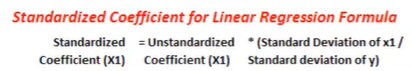

In [15]:
standardized_coef = 0.021 # P value of the coefficient agePossession
un_standardized_coef = standardized_coef * (y_log.std()/X_scaled['agePossession'].std())
un_standardized_coef

np.float64(0.011715539285740215)

In [16]:
normal_coef = np.expm1(un_standardized_coef)
normal_coef

np.float64(0.011784435003403109)

In [17]:
change = 2
new_value = change * normal_coef
new_value

np.float64(0.023568870006806217)

This means that if we increase the agePossession by 1 then the price will increase by 0.011 times. Example: If we increase the agePossession from 1 new to 2 under construction then the price will increase from 0.011 Cr to 0.047 Cr.

## NOTE: This is incomplete and need rework as inference is not correct or close to reality.